# Atlanta Real Estate Market Analysis
## Exploratory Data Analysis using Python & Seaborn


## Overview
This project analyzes Atlanta real estate listings 
to uncover pricing trends, property characteristics, 
and neighborhood patterns across the Atlanta metro area.

## Dataset
Atlanta real estate listings including price, location,
property size, year built, and neighborhood data.

## Tools Used
Python, Pandas, NumPy, Seaborn, Matplotlib

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(palette="Set2", style="whitegrid", 
              rc={"lines.linewidth": 1.5, 
                  "grid.color": "lightgrey",
                  "grid.linestyle": "-",
                  "grid.linewidth": 0.1})

In [3]:
df = pd.read_csv("real_estate_ga_modified.csv")
df.sample(5)

,id,countyId,cityId,is_bankOwned,is_forAuction,event,time,price,pricePerSquareFoot,city,...,parking,garageSpaces,hasGarage,levels,pool,spa,isNewConstruction,hasPetsAllowed,homeType,county
10702,30222-2098674808,19726,55925,0,0,Listed for sale,4/8/2021,581000,0,Greenville,...,0,0,0,0,0,0,0,0,LOT,Meriwether County
8073,31405-108584897,276866,47584,0,0,Listing removed,7/10/2021,129000,0,Savannah,...,0,0,0,0,0,0,0,0,LOT,Chatham County
9604,31558-2074591918,323890,40706,0,0,Listing removed,7/10/2021,95900,0,Saint Marys,...,0,0,0,0,0,0,0,0,LOT,Camden County
806,31220-2070095624,33662,32626,0,0,Listed for sale,6/17/2021,664330,0,Macon,...,0,0,0,0,0,0,0,0,LOT,Bibb County
8691,30513-228800532,289292,23748,0,0,Listed for sale,7/12/2021,289900,0,Blue Ridge,...,0,0,0,0,0,0,0,0,SINGLE_FAMILY,Fannin County


## Dataset Overview
We begin by loading the dataset and generating summary 
statistics for both numerical and categorical features 
to understand the data structure, value ranges, and 
potential quality issues before analysis.

In [5]:
# Summary of numerical variables
df.describe()


,countyId,cityId,is_bankOwned,is_forAuction,price,pricePerSquareFoot,yearBuilt,zipcode,longitude,latitude,...,bathrooms,bedrooms,buildingArea,parking,garageSpaces,hasGarage,pool,spa,isNewConstruction,hasPetsAllowed
count,13803.000000,13803.000000,13803.000000,13803.000000,1.380300e+04,13803.000000,13803.000000,13803.000000,13803.000000,13803.000000,...,13803.000000,13803.000000,13803.000000,13803.000000,13803.000000,13803.000000,13803.000000,13803.000000,13803.000000,13803.000000
mean,142662.084837,32139.893719,0.000145,0.000435,3.671090e+05,101.938347,1347.390567,30670.259654,-83.776617,33.345782,...,1.877998,2.348547,1177.075129,0.460262,0.488300,0.354778,0.054408,0.060711,0.045787,0.003840
std,98059.705183,37907.786930,0.012037,0.020845,6.478566e+05,121.735696,928.131914,557.068903,1.050702,1.060890,...,1.886286,2.076569,1813.755372,0.498436,0.929435,0.478463,0.226830,0.238809,0.209031,0.061849
min,17.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,30002.000000,-85.583374,30.626259,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,58012.500000,13709.000000,0.000000,0.000000,9.500000e+04,0.000000,0.000000,30206.000000,-84.456635,32.623348,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,116675.000000,29242.000000,0.000000,0.000000,2.470000e+05,95.000000,1965.000000,30530.000000,-84.070831,33.700333,...,2.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,227609.500000,43250.000000,0.000000,0.000000,4.250000e+05,161.000000,1999.000000,31061.000000,-83.358616,34.038994,...,3.000000,4.000000,1996.500000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,333689.000000,397383.000000,1.000000,1.000000,3.050400e+07,3353.000000,9999.000000,31909.000000,-80.841385,34.993996,...,89.000000,89.000000,87120.000000,1.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
# Summary of categorical variables
df.describe(include=['object', 'category'])

,id,event,time,city,streetAddress,lotAreaUnits,levels,homeType,county
count,13803,13803,13803,13803,13803,13803,13803,13803,13803
unique,12545,6,577,536,12451,2,41,5,149
top,30161-2070194652,Listed for sale,7/10/2021,Atlanta,Coming Soon Plan,Acres,0,SINGLE_FAMILY,Fulton County
freq,2,9519,2030,1031,30,9797,6524,8110,1168


## Feature Analysis
Here we identify which features are numerical and which 
are categorical. Understanding feature types is essential 
before applying any transformations or visualizations.

In [7]:

num_vars = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical features:", len(num_vars))


Numerical features: 22


In [8]:
cat_vars = df.select_dtypes(include=['object', 'category']).columns
print("Categorical features:", len(cat_vars))

Categorical features: 9


## 3. Data Type Corrections
Some features like zipcode and cityId are stored as 
numbers but actually represent categories. We convert 
them to the correct data type to ensure accurate 
analysis and visualization.

In [9]:

df['zipcode'] = df['zipcode'].astype('category')



In [10]:
df['cityId'] = df['cityId'].astype('category')

## 4. Distribution of Numerical Features

We plot histograms for all continuous numerical features 
to understand their distributions, identify skewness, 
and detect potential outliers before deeper analysis.

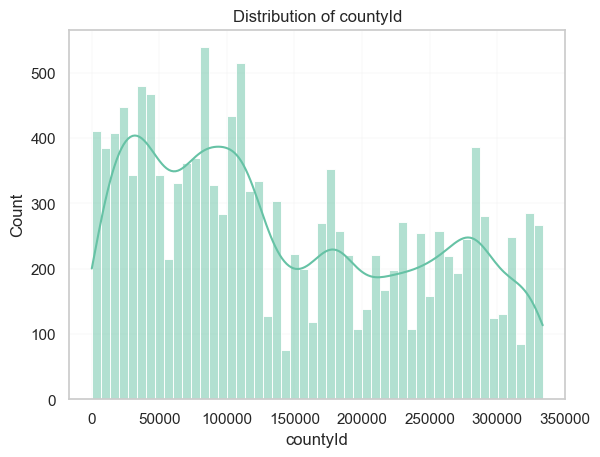

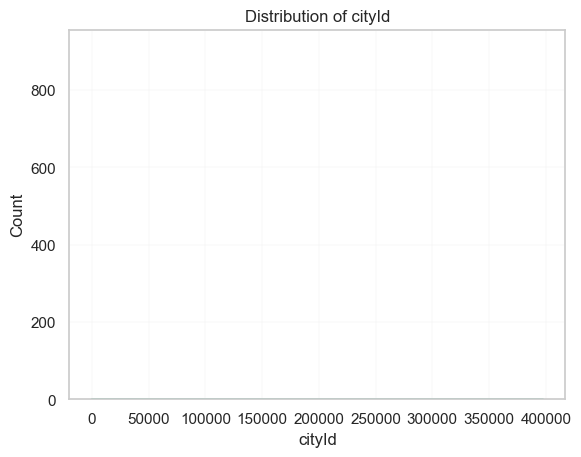

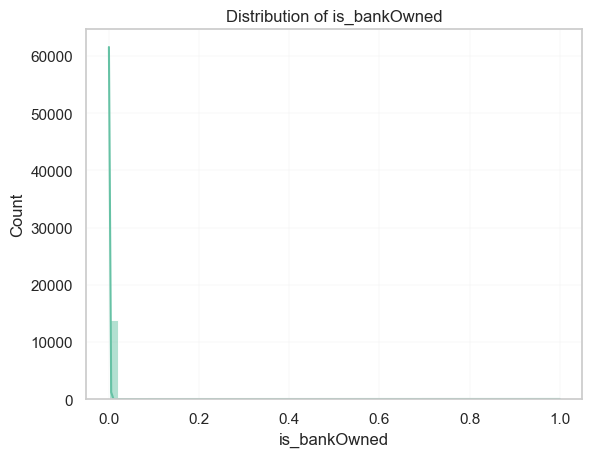

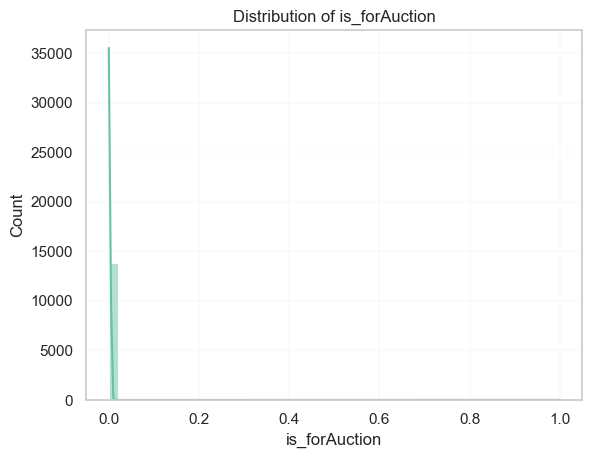

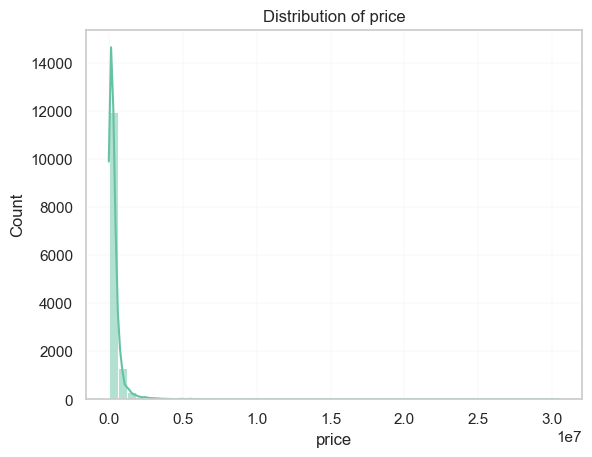

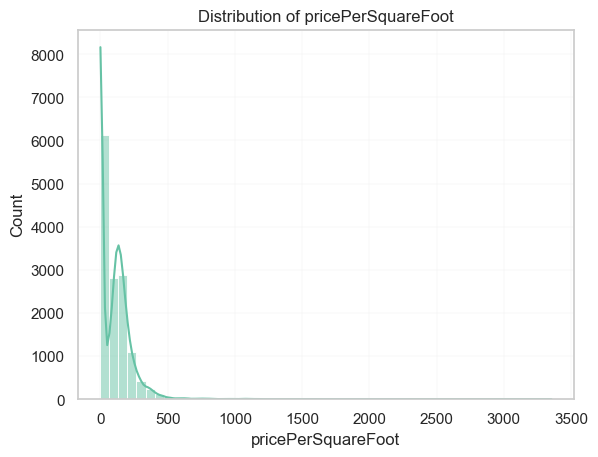

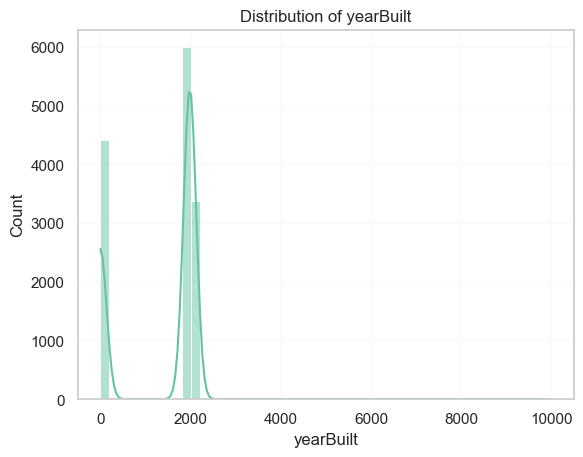

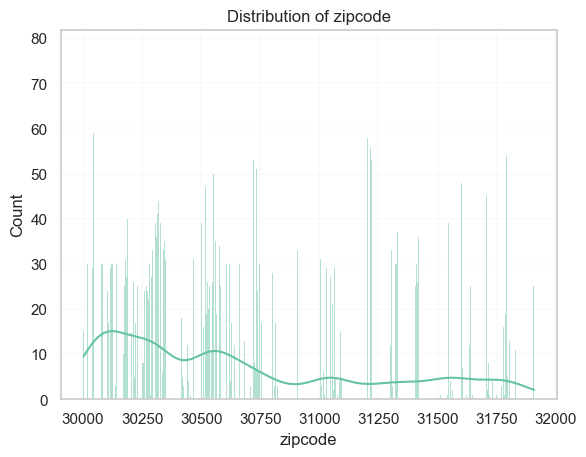

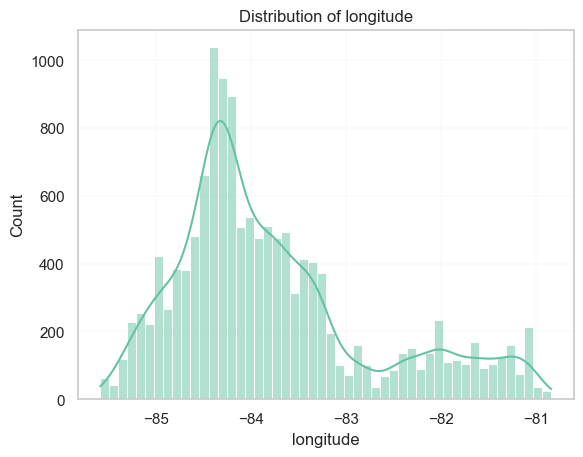

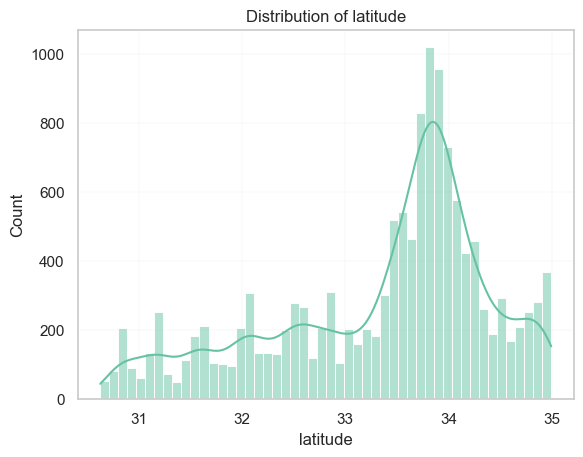

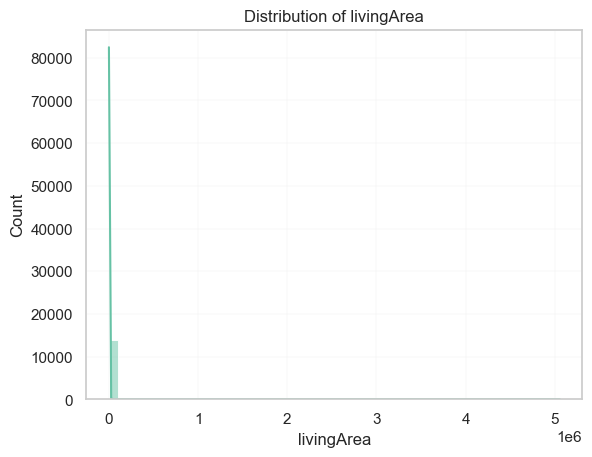

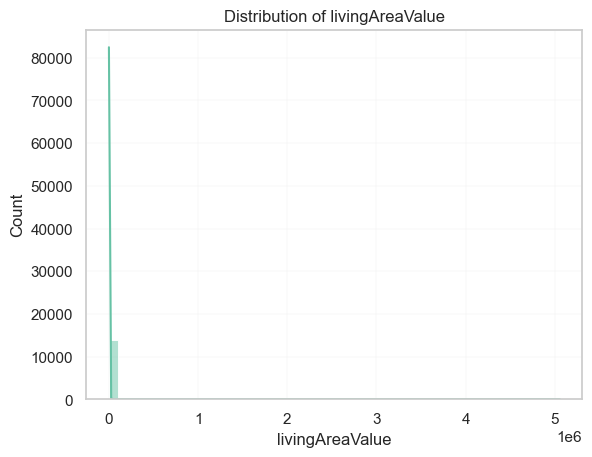

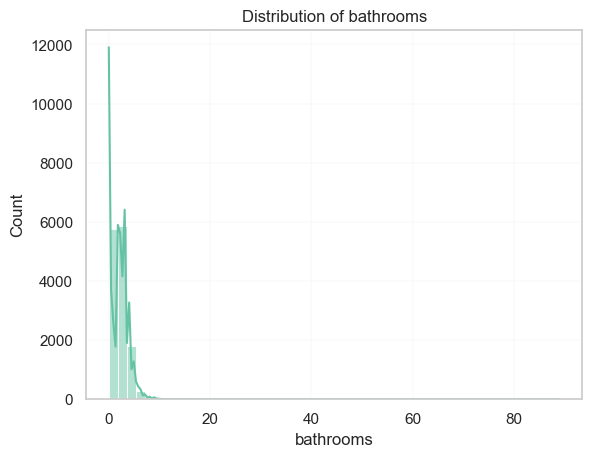

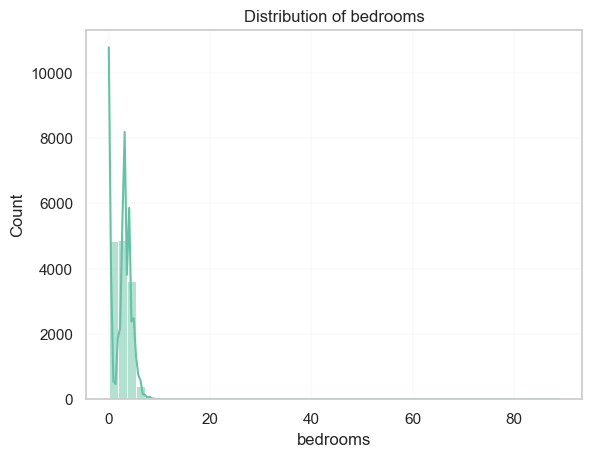

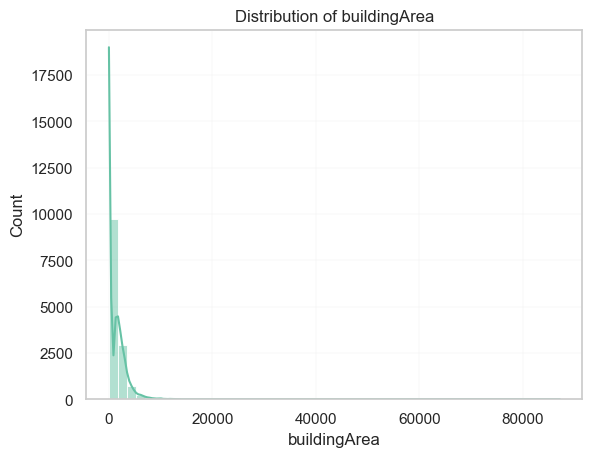

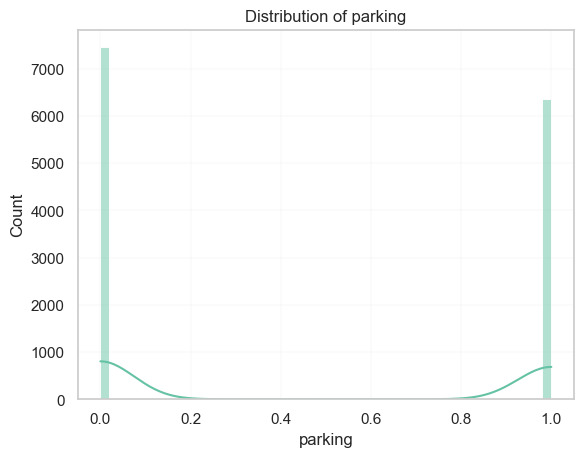

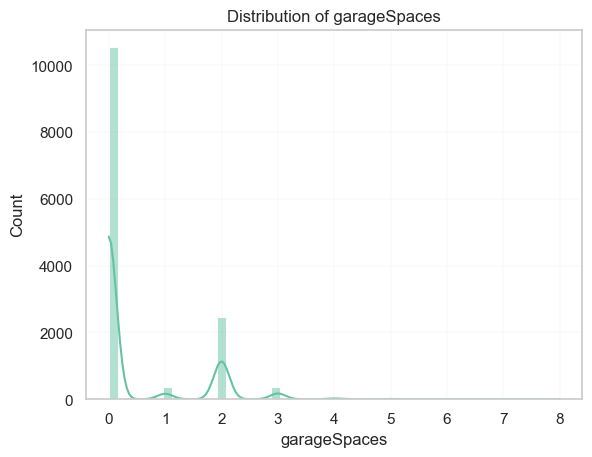

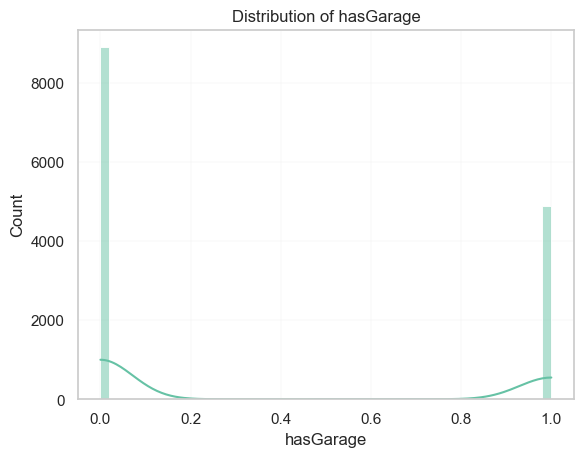

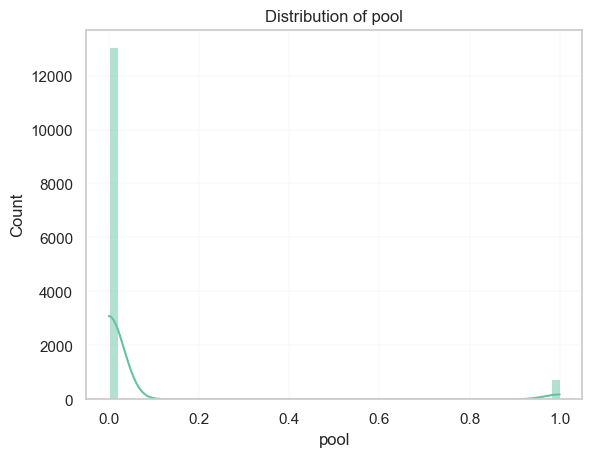

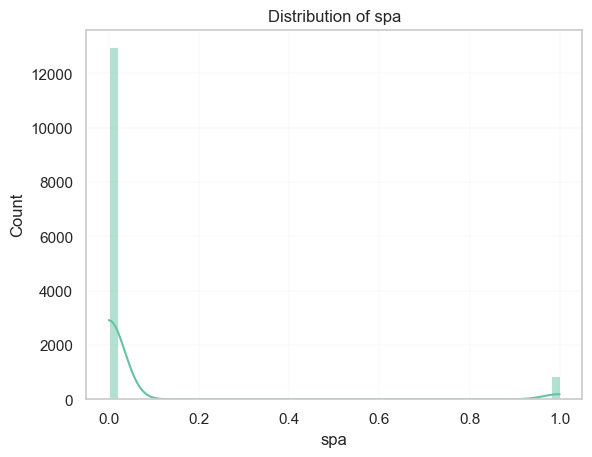

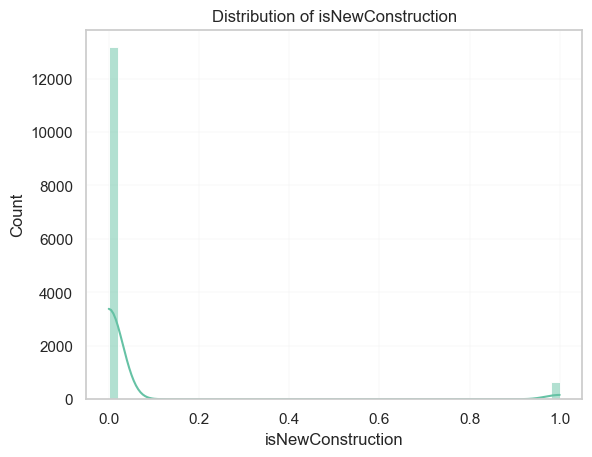

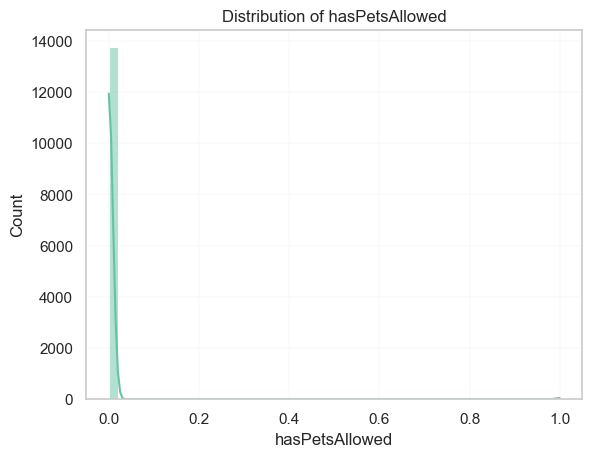

In [11]:
for col in num_vars:
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


## 5. Handling Skewed Data
Several features show highly right-skewed distributions 
making patterns difficult to interpret. We apply log 
transformation to compress the scale and reveal clearer 
patterns in the data.

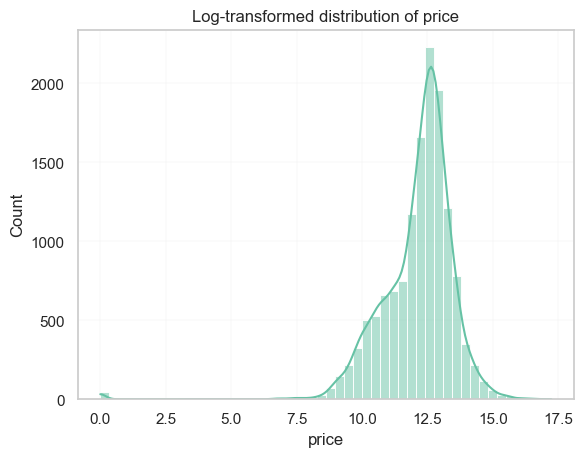

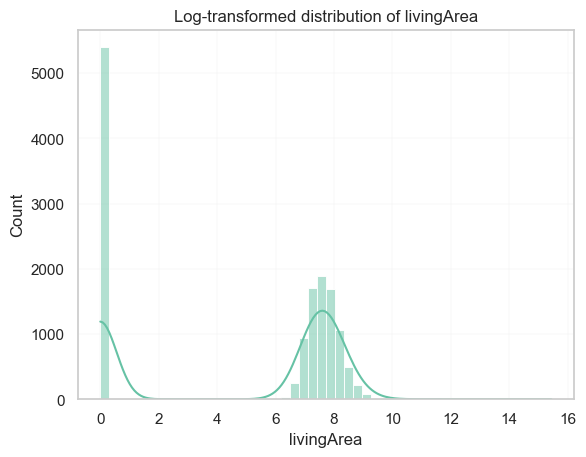

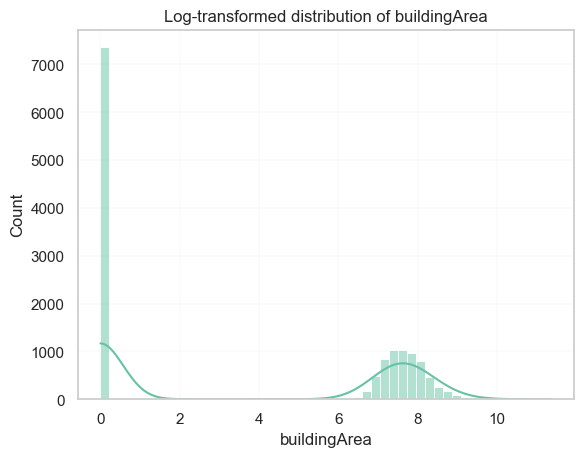

In [12]:
skewed_vars = ['price', 'livingArea', 'buildingArea']
for col in skewed_vars:
    sns.histplot(np.log1p(df[col]), bins=50, kde=True)
    plt.title(f"Log-transformed distribution of {col}")
    plt.show()


## 6. Handling Invalid Values Before Log Transformation
Log transformation fails on zero and negative values. 
Before applying it to the price column we remove rows 
with zero or negative prices which represent missing 
or erroneous data entries.

In [14]:
df = df[df['price'] > 0]
df['log_price'] = np.log1p(df['price'])


## 7. Property Age Analysis — Year Built Distribution
The yearBuilt column contains zero values representing 
missing data and erroneous entries with unrealistic years. 
These were removed before visualization to ensure an 
accurate representation of property age across Atlanta listings.

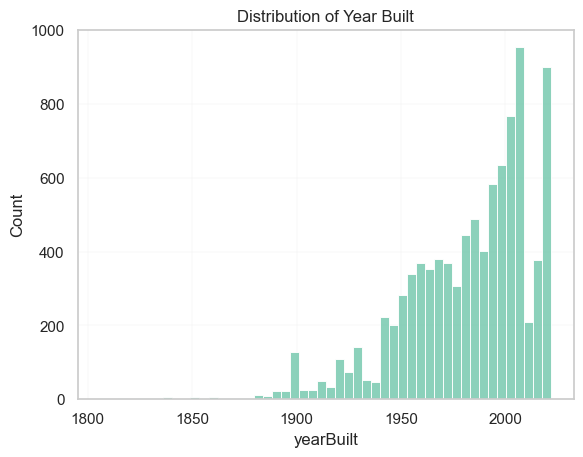

In [13]:
df = df[(df['yearBuilt'] > 1800) & (df['yearBuilt'] <= 2025)]
sns.histplot(df['yearBuilt'], bins=50, kde=False)
plt.title("Distribution of Year Built")
plt.show()


## 8. Distribution of Binary and Low-Cardinality Features
Features with 4 or fewer categories are visualized 
together using count plots. This allows us to quickly 
understand the balance of key binary variables like 
garage availability and new construction status.


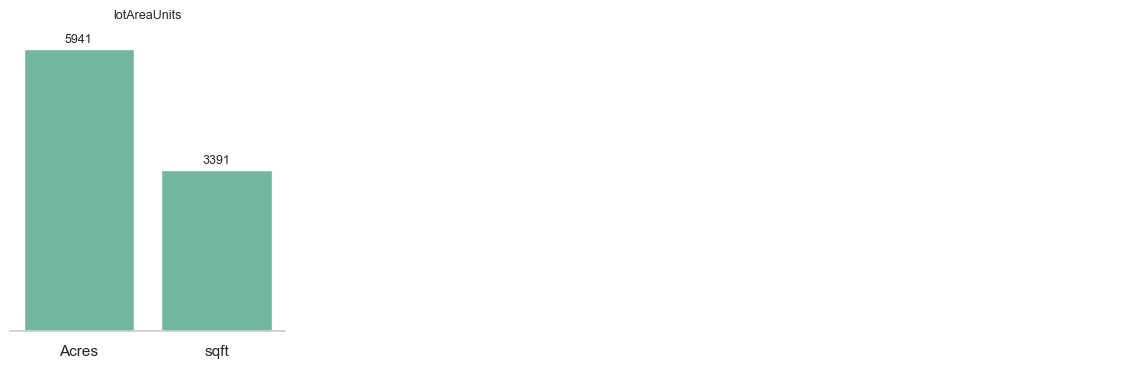

In [15]:
typeone_features = [col for col in df.select_dtypes(include=['category', 'object']).columns if df[col].nunique() <= 4]
df_melted = df[typeone_features].melt(var_name='Feature', value_name='Value')

g = sns.catplot(
    data=df_melted,
    x='Value',
    col='Feature',
    kind='count',
    col_wrap=3,   
    height=4,
    aspect=1,
    sharex=False,
    sharey=False
)

for ax in g.axes.flat:
    ax.set_xlabel('')
    ax.set_ylabel('')      
    ax.set_yticks([])  
    ax.tick_params(left=False, bottom=False)
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', fontsize=9, padding=3)

g.figure.subplots_adjust(hspace=0.4, wspace=0.5)
g.set_titles("{col_name}", size=9, pad=12)
sns.despine(left=True)

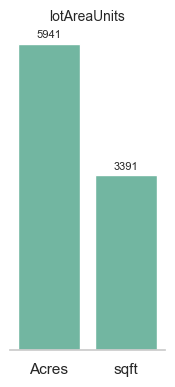

In [16]:
typeone_features = [col for col in df.select_dtypes(include=['category', 'object']).columns if df[col].nunique() <= 4]

ROWS, COLS = 3, 3
fig, axs = plt.subplots(ROWS, COLS, figsize=(COLS * 4, ROWS * 5))
axs = axs.flatten() 
plt.subplots_adjust(hspace=0.3, wspace=1.5)

for i, feature in enumerate(typeone_features): 
    ax = axs[i]
    sns.countplot(data=df, x=feature, ax=ax)
    ax.set_title(feature, size=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_yticks([])
    ax.tick_params(left=False, axis='y', labelsize=9)
    sns.despine(ax=ax, left=True)
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', fontsize=8, padding=3)


for j in range(i + 1, len(axs)):
    axs[j].set_visible(False)


## 9. Distribution of Medium-Cardinality Features
Features with between 5 and 49 unique categories are 
visualized individually. These mid-range categorical 
features often reveal meaningful patterns in property 
types and neighborhood characteristics.


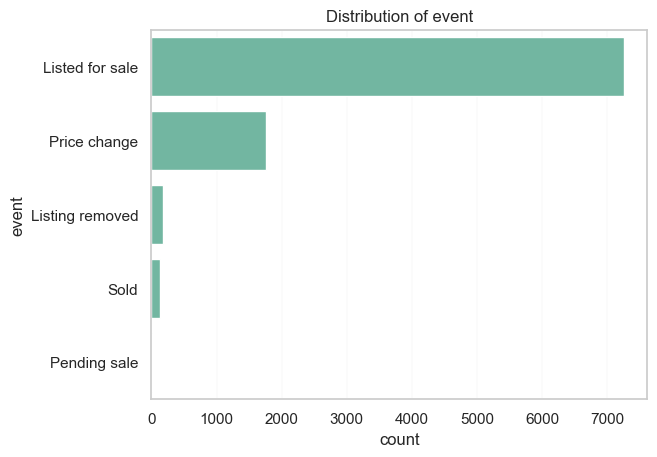

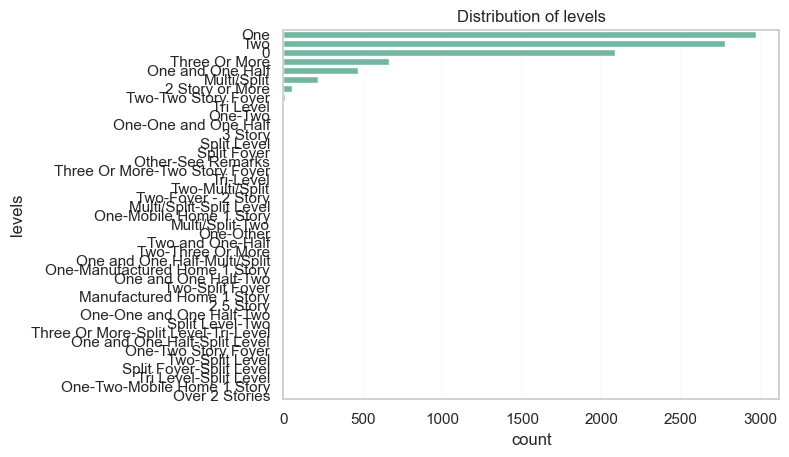

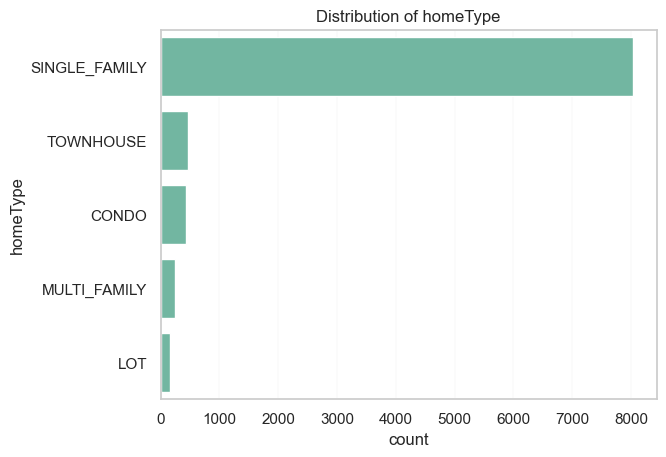

In [17]:
features = [col for col in cat_vars if 5 <= df[col].nunique() <= 49]

for feature in features:
    order = df[feature].value_counts().index
    sns.countplot(data=df, y=feature, order=order)
    plt.title(f"Distribution of {feature}")
    plt.show()


## 10. Listings Over Time.
We analyze how the volume of real estate listings 
changed over time by extracting the year from the 
listing date. This reveals market activity trends 
and seasonal patterns in the Atlanta real estate market.


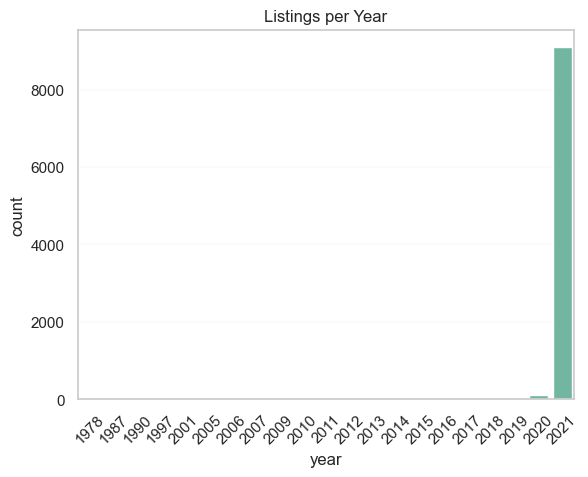

In [18]:
df['time'] = pd.to_datetime(df['time'])
df['year'] = df['time'].dt.year

sns.countplot(data=df, x='year', order=sorted(df['year'].unique()))
plt.xticks(rotation=45)
plt.title("Listings per Year")
plt.show()


## 11. Yearly Listing Trends
To simplify the time visualization we group older 
years together and display individual years from 
2019 onwards where data volume is most significant. 
This reveals the clear growth in listings in recent years.

/var/folders/np/q2tzm8q907xb6czg03sz9bwc0000gn/T/ipykernel_53761/738478987.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="year_grouped", data=df, order=order, palette="Set2")


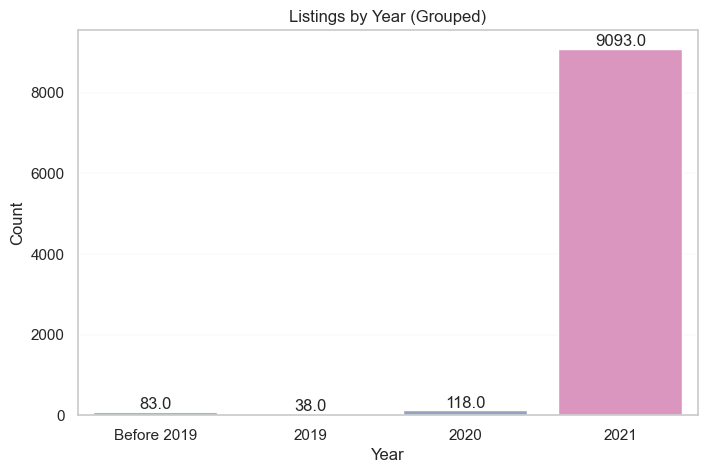

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create the grouped year column
df["year_grouped"] = df["year"].apply(lambda x: "Before 2019" if x < 2019 else str(x))

# Set order so "Before 2019" comes first, then the rest sorted
order = ["Before 2019"] + sorted([y for y in df["year_grouped"].unique() if y != "Before 2019"])

# Plot
plt.figure(figsize=(8,5))
ax = sns.countplot(x="year_grouped", data=df, order=order, palette="Set2")

# Add value labels
for p in ax.patches:
    ax.annotate(
        str(p.get_height()), 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha="center", va="bottom"
    )

plt.title("Listings by Year (Grouped)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()


## 12. Geographic Distribution of Listings
We visualize the top 15 most frequent values for 
county, zipcode, city, and cityId to understand 
which areas of Atlanta have the highest real estate 
activity and listing density.

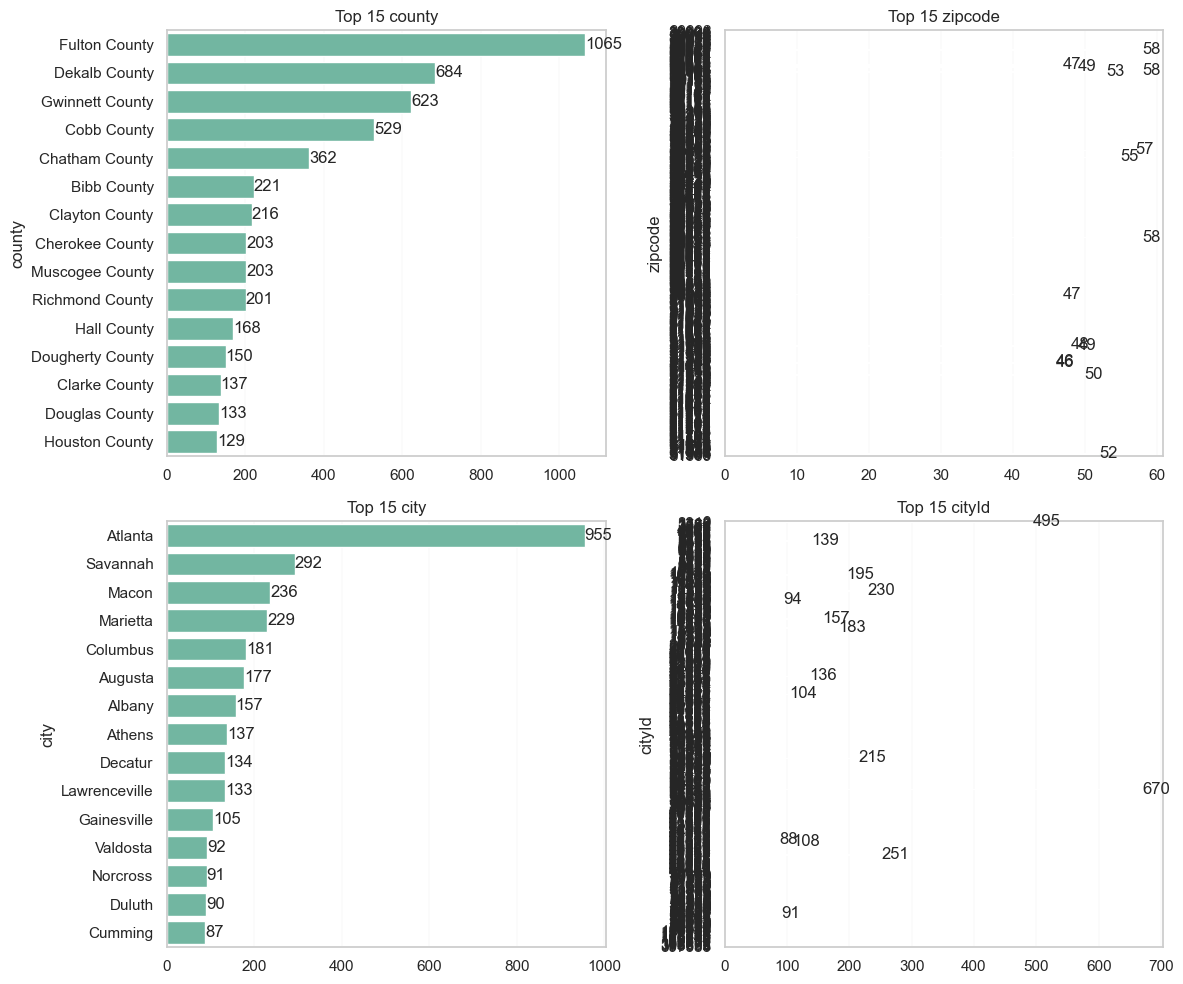

In [20]:
features = ['county', 'zipcode', 'city', 'cityId']
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

for ax, feature in zip(axs.flatten(), features):
    top15 = df[feature].value_counts().nlargest(15)
    sns.barplot(x=top15.values, y=top15.index, ax=ax)
    ax.set_title(f"Top 15 {feature}")
    for container in ax.containers:
        ax.bar_label(container)
plt.tight_layout()
plt.show()


## 13. Spotlight — Dekalb County.  
Dekalb County is highlighted among all Atlanta counties 
to draw attention to its position in the market. This 
technique is useful when presenting findings to 
stakeholders who need to focus on a specific area.

/var/folders/np/q2tzm8q907xb6czg03sz9bwc0000gn/T/ipykernel_53761/1233508129.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top15.values, y=top15.index, palette=colors)


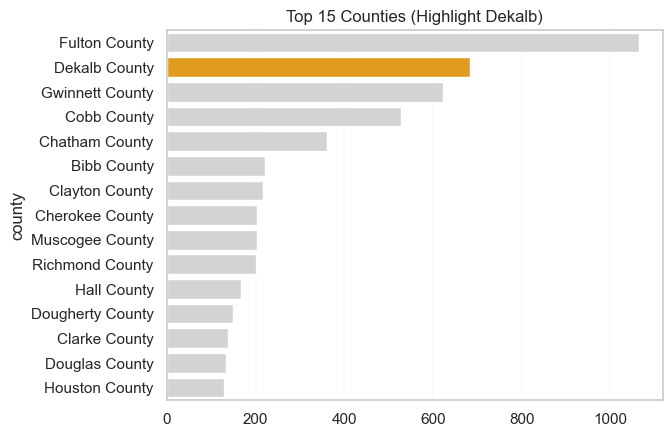

In [21]:
top15 = df['county'].value_counts().nlargest(15)
colors = ['orange' if c == 'Dekalb County' else 'lightgray' for c in top15.index]

sns.barplot(x=top15.values, y=top15.index, palette=colors)
plt.title("Top 15 Counties (Highlight Dekalb)")
plt.show()


## 14. Feature Correlations
A correlation heatmap reveals the strength and direction 
of relationships between numerical features. This helps 
identify which variables are most closely related to 
price and which features may be redundant.


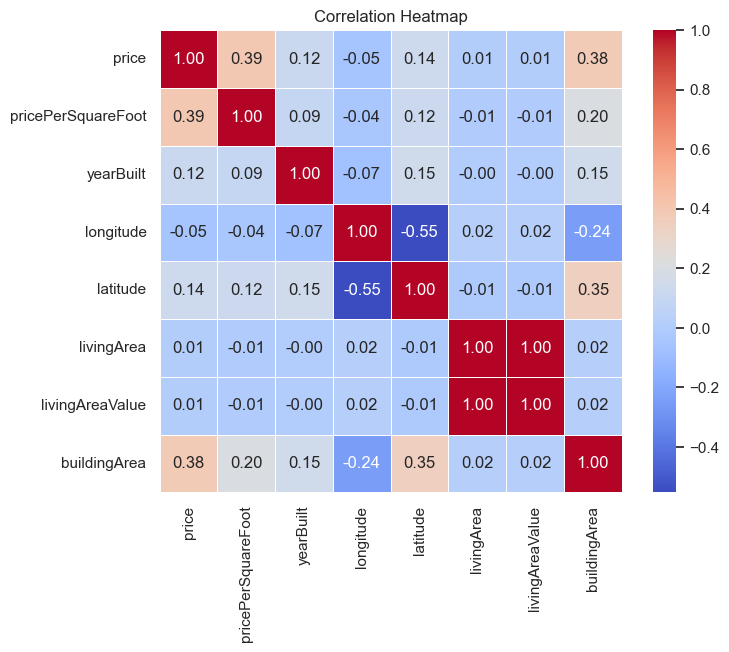

In [22]:
features = ['price', 'pricePerSquareFoot', 'yearBuilt', 'longitude',
            'latitude', 'livingArea', 'livingAreaValue', 'buildingArea']

corr = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()



## 15. Relationships Between Key Pricing Variables
A scatter plot matrix allows us to simultaneously 
visualize relationships between multiple pricing 
variables. Log transformation is applied to handle 
skewness and reveal clearer linear relationships.

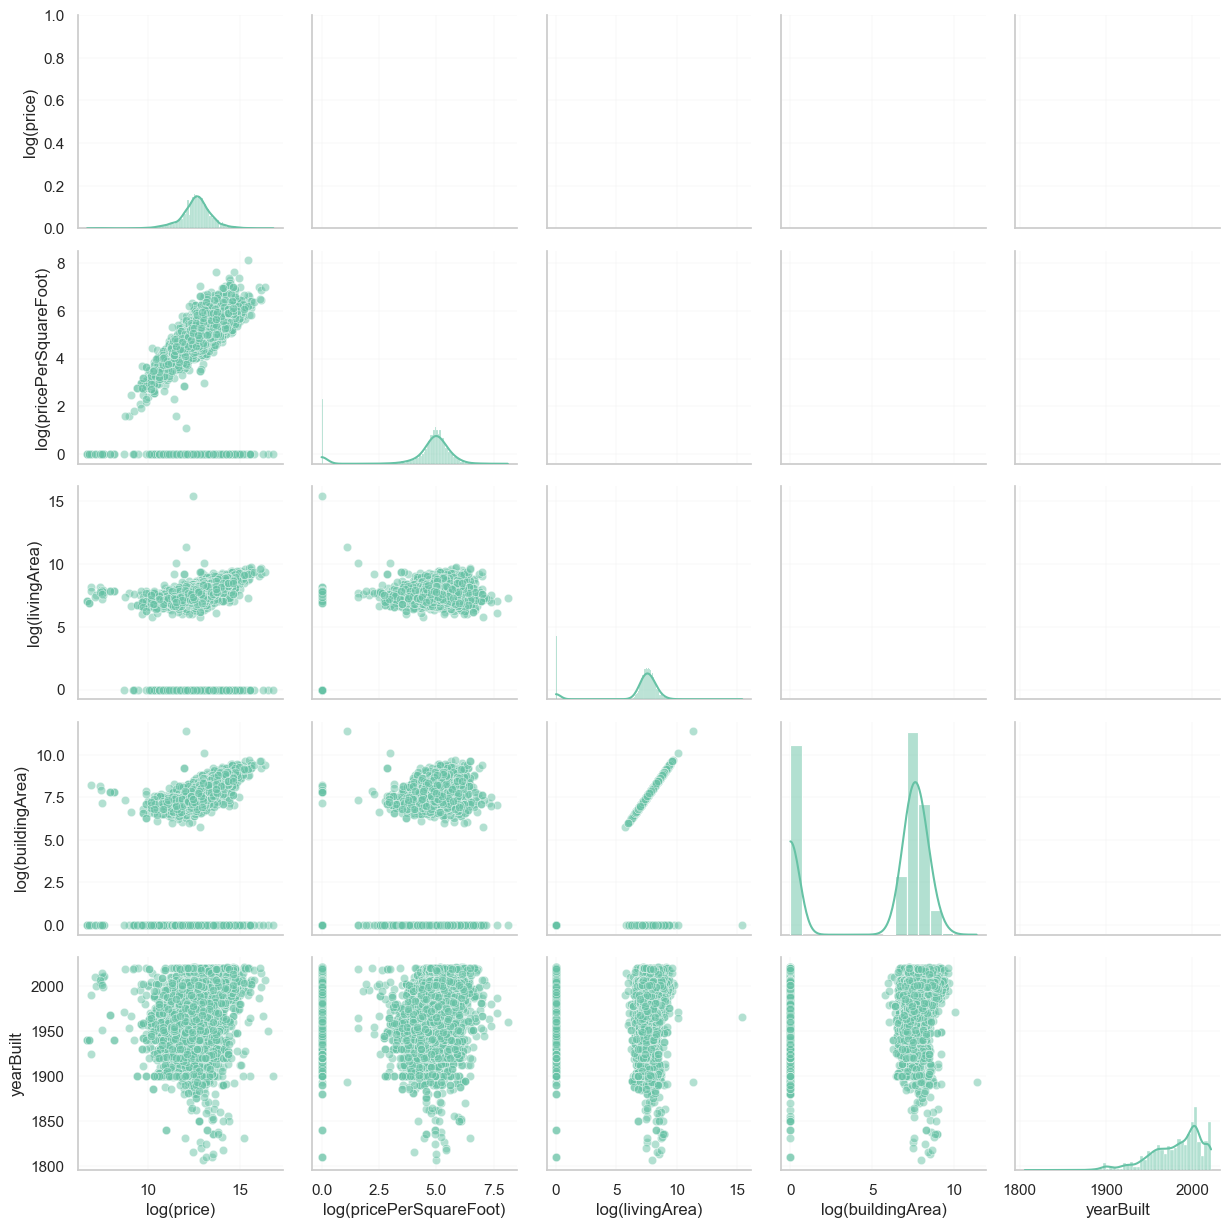

In [23]:
log_features = ['price', 'pricePerSquareFoot', 'livingArea', 'buildingArea']
df_log = df.copy()
for col in log_features:
    df_log[f'log({col})'] = np.log1p(df_log[col])

cols = [f'log({col})' for col in log_features] + ['yearBuilt']

g = sns.PairGrid(df_log[cols])
g.map_lower(sns.scatterplot, alpha=0.5)
g.map_diag(sns.histplot, kde=True)
g.map_upper(lambda *args, **kwargs: None)
plt.show()



## 16. Scatter Plot Matrix 
A scatter plot matrix allows us to simultaneously 
visualize relationships between multiple pricing 
variables. Log transformation is applied to handle 
skewness and reveal clearer linear relationships.


/var/folders/np/q2tzm8q907xb6czg03sz9bwc0000gn/T/ipykernel_53761/2605605188.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[f'log({col})'] = np.log1p(df_filtered[col])
/var/folders/np/q2tzm8q907xb6czg03sz9bwc0000gn/T/ipykernel_53761/2605605188.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[f'log({col})'] = np.log1p(df_filtered[col])
/var/folders/np/q2tzm8q907xb6czg03sz9bwc0000gn/T/ipykernel_53761/2605605188.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy

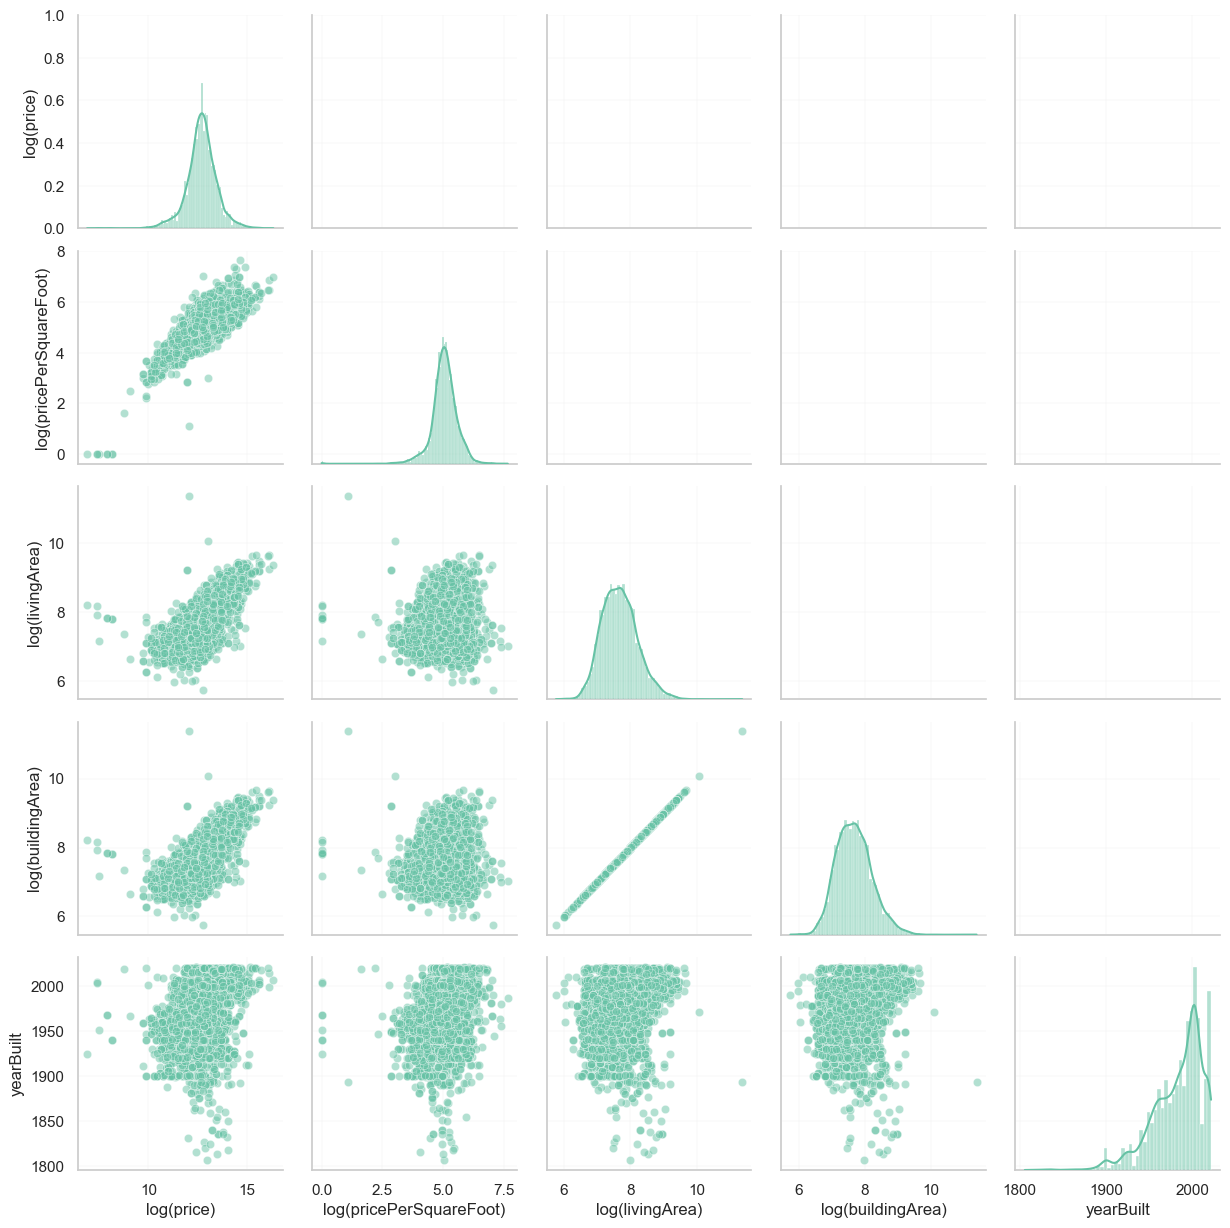

In [25]:

df_filtered = df[(df['price'] > 0) & (df['livingArea'] > 0) & (df['buildingArea'] > 0)]
for col in log_features:
    df_filtered[f'log({col})'] = np.log1p(df_filtered[col])

cols = [f'log({col})' for col in log_features] + ['yearBuilt']

g = sns.PairGrid(df_filtered[cols])
g.map_lower(sns.scatterplot, alpha=0.5)
g.map_diag(sns.histplot, kde=True)
g.map_upper(lambda *args, **kwargs: None)
plt.show()


## 17. Exploring Price vs Living Area Across Home Types
This visualization explores the relationship between 
price and living area across different home types using 
a log-log scale. Color and marker style indicate whether 
the property has a garage. Zero values and extreme 
outliers were removed for clarity.

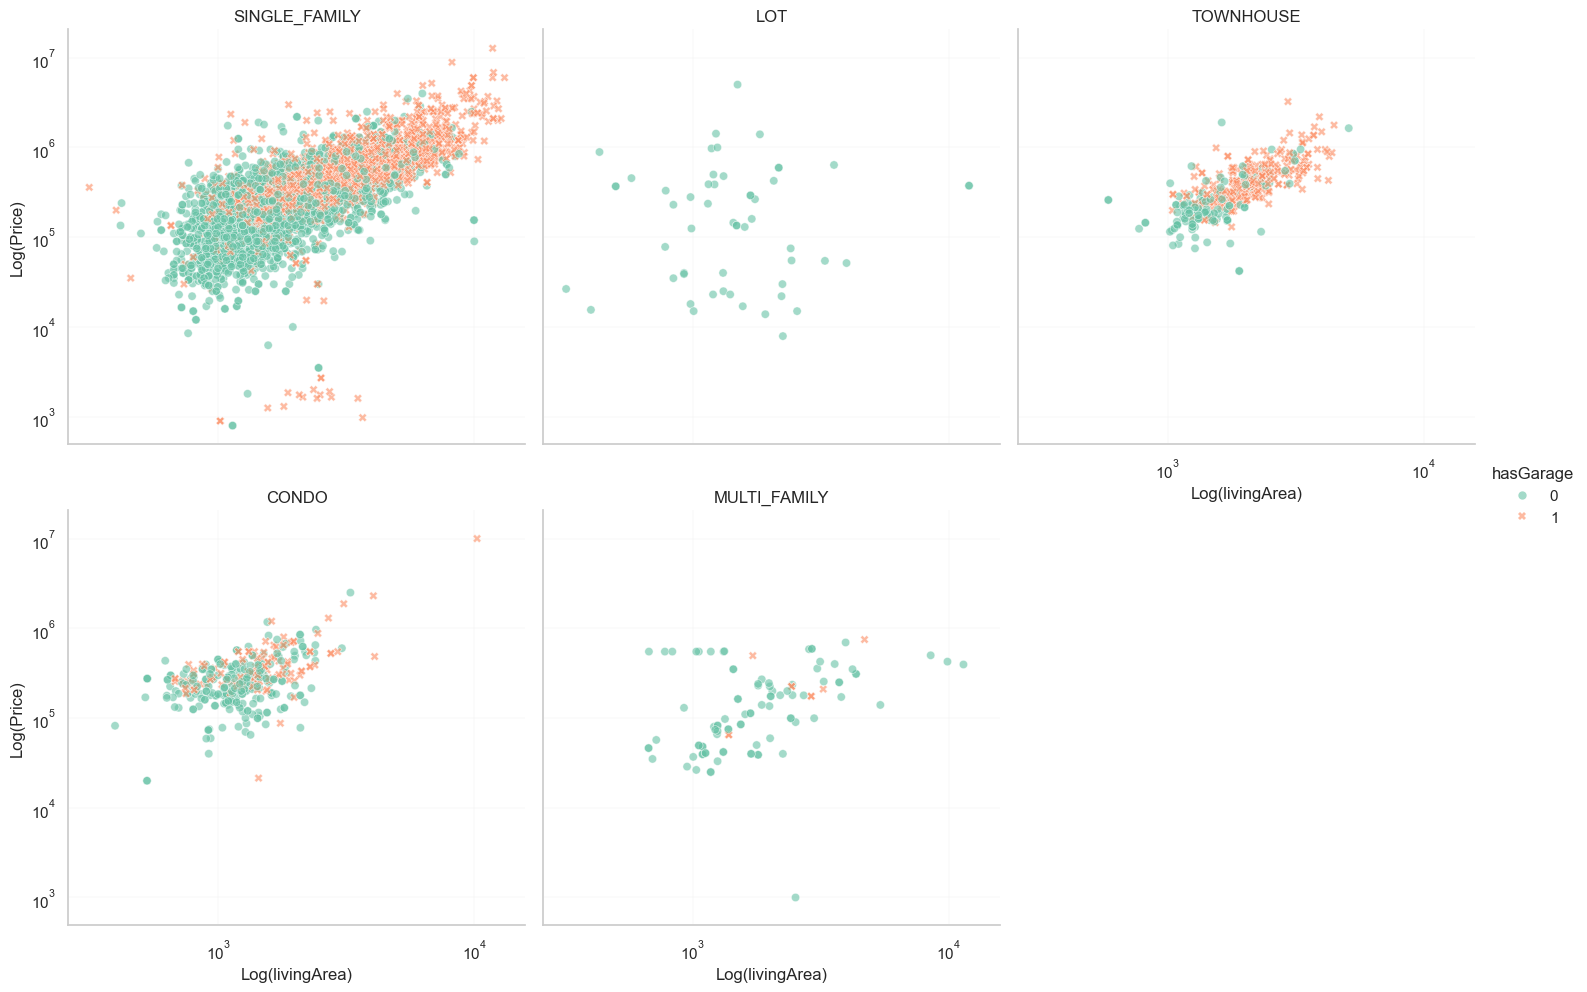

In [26]:
df_filtered = df[(df['price'] > 0) & (df['livingArea'] > 0) & (df['livingArea'] < 15000)]

g = sns.relplot(
    data=df_filtered,
    x='livingArea',
    y='price',
    col='homeType',
    col_wrap=3,
    hue='hasGarage',
    style='hasGarage',
    kind='scatter',
    alpha=0.6
)

g.set(xscale='log', yscale='log')
g.set_titles("{col_name}")
g.set_axis_labels("Log(livingArea)", "Log(Price)")
sns.despine()


#### The conclusions from small multiples

1. Log-linear relationship between living area and price  
   Across all `homeType` categories, there is a strong *positive log-linear relationship* between `livingArea` and `price`, meaning that price increases proportionally (or more) with living area on a logarithmic scale.

2. Garage presence is linked to higher size and value  
   Homes with a garage (`hasGarage = 1`) consistently appear in the upper-right region of each subplot.  
   These properties tend to be both larger and more expensive than those without garages, suggesting that garage presence is associated with higher-value homes across home types.


## 18. Price vs Year Built by Home Type
This visualization explores how property age relates 
to price across different home types. Year built is 
plotted against price on a log scale, with color 
indicating whether the property is new construction. 
Zero values and extreme outliers were removed for 
clarity.


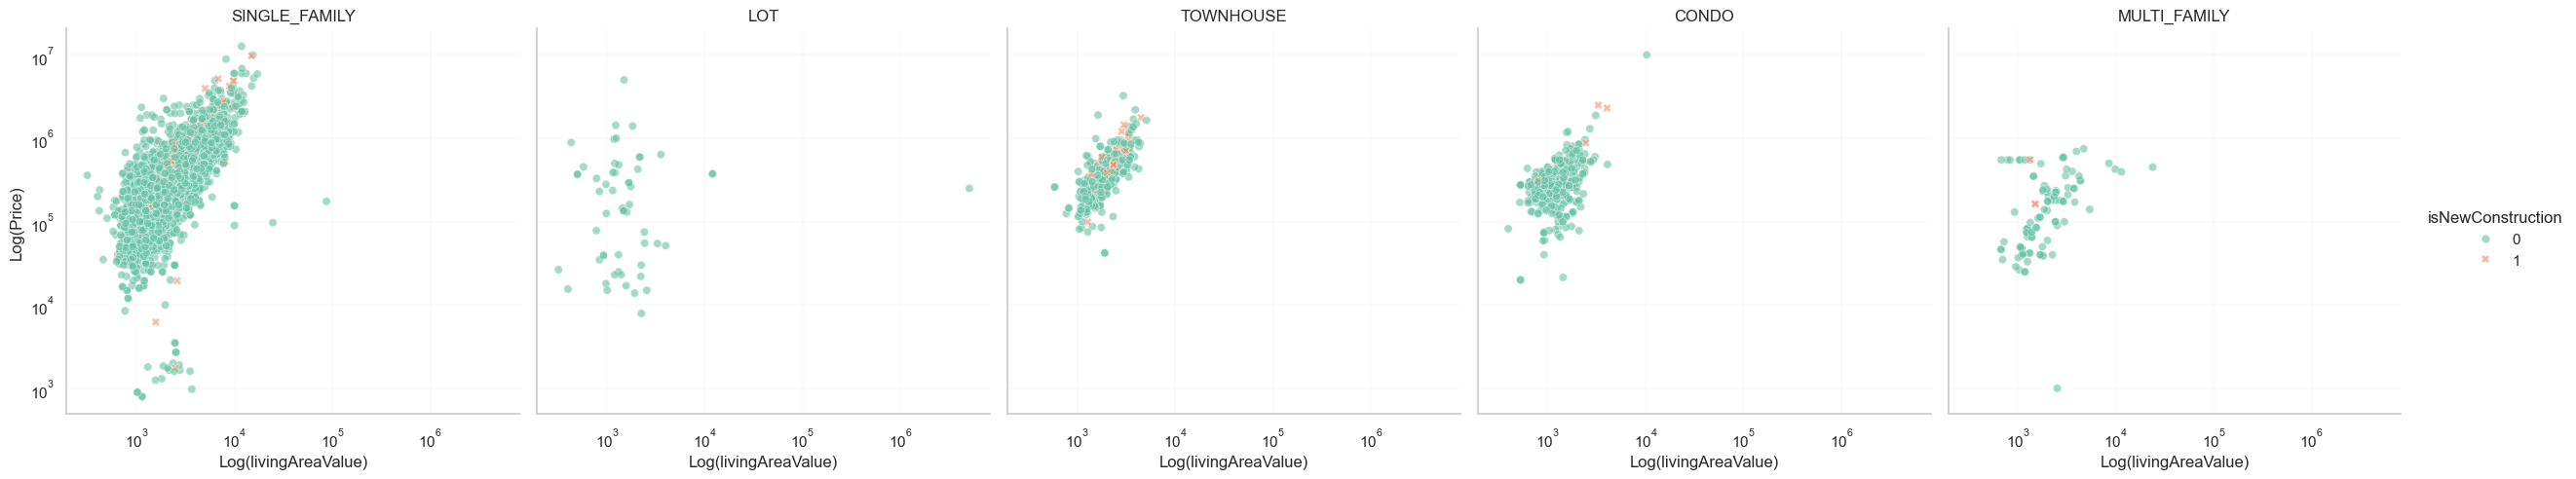

In [27]:
df_filtered = df[(df['price'] > 0) & (df['livingAreaValue'] > 0)]
g = sns.relplot(
    data=df_filtered,
    x='livingAreaValue',
    y='price',
    col='homeType',
    hue='isNewConstruction',
    style='isNewConstruction',
    kind='scatter',
    alpha=0.6
)
g.set(xscale='log', yscale='log')
g.set_titles("{col_name}")
g.set_axis_labels("Log(livingAreaValue)", "Log(Price)")
sns.despine()


**Key Observations:**

1. New constructions tend to cluster at higher prices for similar living area values, showing premium pricing.
2. Older homes display wider variability in price relative to living area, suggesting more heterogeneity in condition and location.

## Key Findings

1. Property prices in Atlanta are highly right-skewed. 
Most listings are affordable but a small number of 
luxury properties significantly raise the average.

2. Living area is the strongest predictor of price. 
Larger homes consistently command higher prices 
across all neighborhoods and home types.

3. Dekalb County dominates listing volume making it 
the most active real estate market in the Atlanta 
metro area.

4. New construction properties command premium prices 
with less price variation than older properties.

5. Real estate listing volume grew significantly 
after 2019 reflecting strong demand in the 
Atlanta housing market.


## Recommendations

1. Investors should prioritize Dekalb County given 
its high listing volume and strong market liquidity.

2. Focus on properties with larger living areas as 
they show the strongest correlation with price 
appreciation over time.

3. New construction properties offer more predictable 
pricing making them lower risk for investment modeling.

4. Apply log transformation to price before any 
predictive modeling as the raw distribution is 
too skewed for accurate results.